In [24]:
import pandas as pd
#1. Custom Functions
# Function 1: data load
def load_data():
    customers = pd.read_csv("customers (3).csv")
    transactions = pd.read_csv("transactions (3).csv")
    return customers, transactions


# Function 2: null values handle 
def handle_nulls(df):
    if "region" in df.columns:
        df["region"] = df["region"].fillna(df["region"].mode()[0])
    return df


# Function 3: outliers remove 
def remove_outliers(df, column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[(df[column_name] >= lower_limit) & (df[column_name] <= upper_limit)]
    return df


# Function 4: total spent calculate 
def calculate_total_spent(transactions_df):
    total_spent = transactions_df.groupby("customer_id")["total_amount"].sum().reset_index()
    total_spent.rename(columns={"total_amount": "total_spent"}, inplace=True)
    return total_spent


# Function 5: days since last purchase calculate
def calculate_days_since_last_purchase(transactions_df):
    latest_date = transactions_df["order_date"].max()

    last_purchase = transactions_df.groupby("customer_id")["order_date"].max().reset_index()
    last_purchase.rename(columns={"order_date": "last_purchase_date"}, inplace=True)

    last_purchase["days_since_last_purchase"] = (
        latest_date - last_purchase["last_purchase_date"]
    ).dt.days

    return last_purchase


# 2. Load Data
customers, transactions = load_dat
# 3. Basic Cleaning

customers["registration_date"] = pd.to_datetime(customers["registration_date"])
transactions["order_date"] = pd.to_datetime(transactions["order_date"])

# null values handle
transactions = handle_nulls(transactions)

# outliers remove  from total_amount
transactions = remove_outliers(transactions, "total_amount")

# 4. Feature Creation

# total_spent feature
total_spent_df = calculate_total_spent(transactions)

# days_since_last_purchase feature
last_purchase_df = calculate_days_since_last_purchase(transactions)

# customers to merge 
customer_data = customers.merge(total_spent_df, on="customer_id", how="left")
customer_data = customer_data.merge(last_purchase_df, on="customer_id", how="left")

customer_data["total_spent"] = customer_data["total_spent"].fillna(0)
customer_data["days_since_last_purchase"] = customer_data["days_since_last_purchase"].fillna(-1)

# 5. Group and Aggregate
segment_summary = customer_data.groupby("customer_segment").agg(
    total_customers=("customer_id", "count"),
    average_total_spent=("total_spent", "mean"),
    maximum_total_spent=("total_spent", "max"),
    average_days_since_last_purchase=("days_since_last_purchase", "mean")
).reset_index()

# 6. Output
print("Cleaned Customer Data:")
print(customer_data.head())

print("\nCustomer Segment Summary:")
print(segment_summary)

Cleaned Customer Data:
   customer_id first_name last_name                      email  \
0            1    Jessica     Brown   jessica.brown1@email.com   
1            2      Susan    Garcia    susan.garcia2@email.com   
2            3      Sarah    Thomas    sarah.thomas3@email.com   
3            4      Linda  Williams  linda.williams4@email.com   
4            5    Charles    Martin  charles.martin5@email.com   

  registration_date region customer_segment  total_spent last_purchase_date  \
0        2023-07-05   West       Occasional          0.0                NaT   
1        2023-11-30   East       Occasional          0.0                NaT   
2        2023-10-31   East          Regular          0.0                NaT   
3        2023-11-04  South       Occasional          0.0                NaT   
4        2023-06-22  North       Occasional          0.0                NaT   

   days_since_last_purchase  
0                      -1.0  
1                      -1.0  
2              

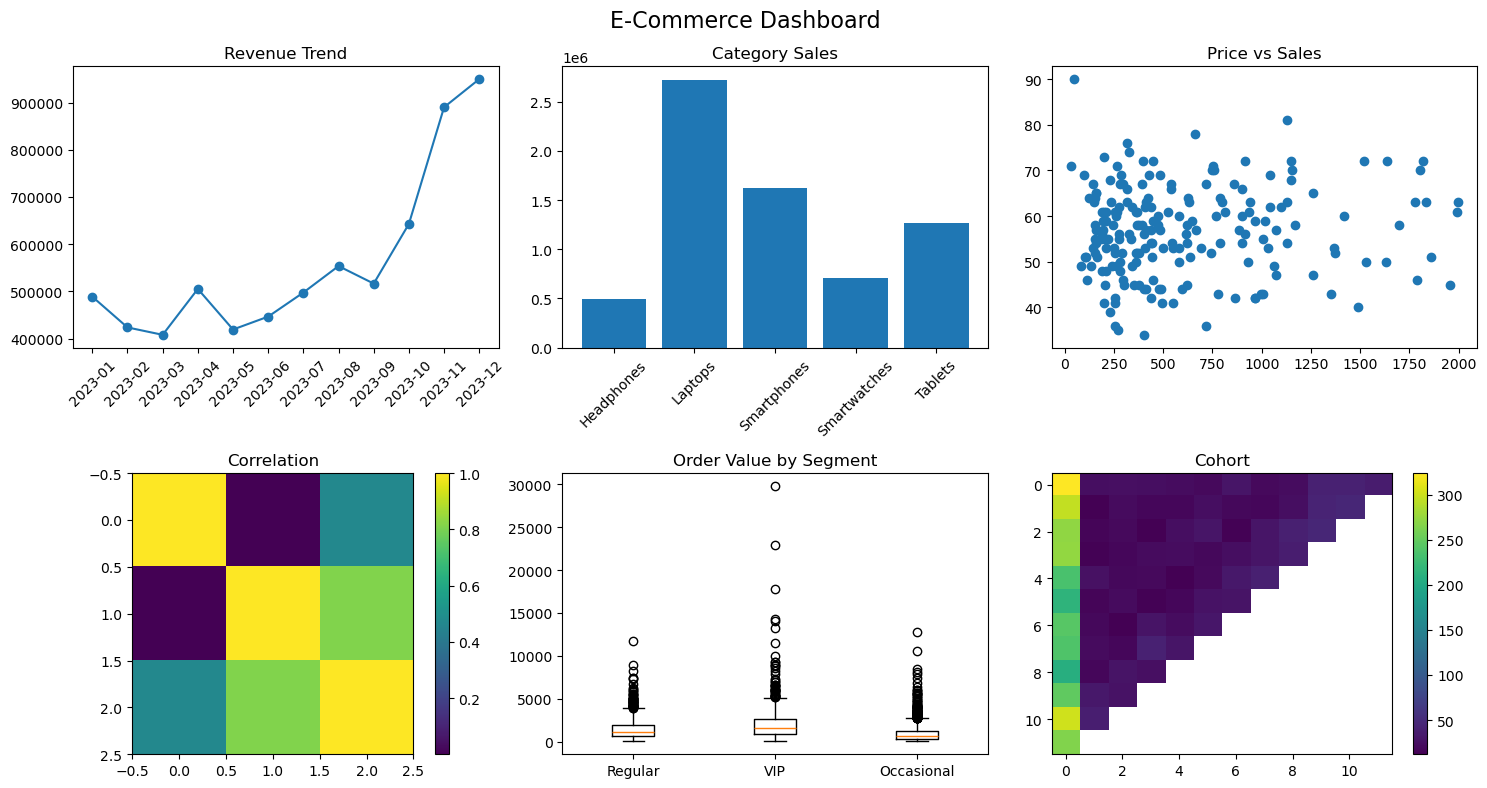

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
transactions = pd.read_csv("./transactions (3).csv")
customers = pd.read_csv("./customers (3).csv")
products = pd.read_csv("./products (2).csv")
order_items = pd.read_csv("./order_items (4).csv")

# Cleaning
transactions["order_date"] = pd.to_datetime(transactions["order_date"])
transactions["month"] = transactions["order_date"].dt.strftime("%Y-%m")

order_items["line_total"] = order_items["quantity"] * order_items["unit_price"]

# Merge
data = pd.merge(order_items, products, on="product_id")
data2 = pd.merge(transactions, customers, on="customer_id")

completed = transactions[transactions["status"] == "Completed"]
completed_seg = data2[data2["status"] == "Completed"]

# Prepare data
rev = completed.groupby("month")["total_amount"].sum()
cat = data.groupby("category")["line_total"].sum()
sales = data.groupby("price")["quantity"].sum()
corr = order_items[["quantity","unit_price","line_total"]].corr()

segments = completed_seg["customer_segment"].dropna().unique()
box_data = [completed_seg[completed_seg["customer_segment"]==s]["total_amount"] for s in segments]

# Cohort
df = completed.copy()
df["order_month"] = df["order_date"].dt.to_period("M")

cohort = df.groupby("customer_id")["order_month"].min().reset_index()
cohort.columns = ["customer_id","cohort_month"]

df = pd.merge(df, cohort, on="customer_id")

df["month_number"] = (
    (df["order_month"].dt.year - df["cohort_month"].dt.year)*12 +
    (df["order_month"].dt.month - df["cohort_month"].dt.month)
)

pivot = df.groupby(["cohort_month","month_number"])["customer_id"].count().unstack()

# DASHBOARD 
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("E-Commerce Dashboard", fontsize=16)

# 1 Revenue
axes[0,0].plot(rev.index, rev.values, marker="o")
axes[0,0].set_title("Revenue Trend")
axes[0,0].tick_params(axis="x", rotation=45)

# 2 Category
axes[0,1].bar(cat.index, cat.values)
axes[0,1].set_title("Category Sales")
axes[0,1].tick_params(axis="x", rotation=45)

# 3 Scatter
axes[0,2].scatter(sales.index, sales.values)
axes[0,2].set_title("Price vs Sales")

# 4 Heatmap
im = axes[1,0].imshow(corr)
axes[1,0].set_title("Correlation")
fig.colorbar(im, ax=axes[1,0])

# 5 Boxplot
axes[1,1].boxplot(box_data)
axes[1,1].set_xticks(range(1,len(segments)+1))
axes[1,1].set_xticklabels(segments)
axes[1,1].set_title("Order Value by Segment")

# 6 Cohort
im2 = axes[1,2].imshow(pivot, aspect="auto")
axes[1,2].set_title("Cohort")
fig.colorbar(im2, ax=axes[1,2])

plt.tight_layout()
plt.show()

In [22]:
import pandas as pd

# Load data
products = pd.read_csv("products (2).csv")
transactions = pd.read_csv("transactions (3).csv")
order_items = pd.read_csv("order_items (4).csv")

# Merge
df = order_items.merge(products, on="product_id")
df = df.merge(transactions, on="order_id")

# Revenue
df["revenue"] = df["quantity"] * df["unit_price"]

 
# Top 10 Products
top = df.groupby("product_name")["revenue"].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Products:\n", top)

# Bottom 10 Products
 
bottom = df.groupby("product_name")["revenue"].sum().sort_values().head(10)
print("\nBottom 10 Products:\n", bottom)

 
# Popular Categories
cat = df.groupby("category")["revenue"].sum().sort_values(ascending=False)
print("\nPopular Categories:\n", cat)
 
# Peak Hours (simple)
 
df["order_date"] = pd.to_datetime(df["order_date"])
df["hour"] = df["order_date"].dt.hour

hours = df.groupby("hour")["order_id"].count()
print("\nOrders by Hour:\n", hours)

 
# Outliers (simple)
Q1 = df["revenue"].quantile(0.25)
Q3 = df["revenue"].quantile(0.75)

outliers = df[(df["revenue"] < Q1) | (df["revenue"] > Q3)]
print("\nOutliers:\n", outliers[["product_name", "revenue"]].head())


Top 10 Products:
 product_name
ASUS Laptop Model 14     128465.88
HP Laptop Model 30       124079.93
ASUS Laptop Model 25     123821.89
ASUS Laptop Model 34     119357.23
HP Laptop Model 16       115230.73
Apple Laptop Model 29    112655.76
ASUS Laptop Model 35     110295.12
HP Laptop Model 8        107257.08
Lenovo Laptop Model 7     96222.11
ASUS Laptop Model 40      92355.76
Name: revenue, dtype: float64

Bottom 10 Products:
 product_name
Apple Headphone Model 11         2138.99
JBL Headphone Model 7            3880.87
Bose Headphone Model 27          4049.46
Sennheiser Headphone Model 10    5022.60
Bose Headphone Model 2           5029.77
Garmin Smartwatche Model 40      5260.70
Fossil Smartwatche Model 4       6311.98
JBL Headphone Model 6            6490.93
Samsung Smartwatche Model 36     7345.67
Apple Headphone Model 31         7524.03
Name: revenue, dtype: float64

Popular Categories:
 category
Laptops         2723710.83
Smartphones     1623761.96
Tablets         1267188.43
S

In [23]:
import pandas as pd
from datetime import timedelta
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Load data
transactions = pd.read_csv("transactions (3).csv")

# Convert date
transactions["order_date"] = pd.to_datetime(transactions["order_date"])

 
# RFM FEATURES
today = transactions["order_date"].max()

rfm = transactions.groupby("customer_id").agg({
    "order_date": lambda x: (today - x.max()).days,   # Recency
    "order_id": "count",                             # Frequency
    "total_amount": "sum"                            # Monetary
})

rfm.columns = ["recency", "frequency", "monetary"]

# TARGET (Churn)
# If last purchase > 60 days → churn = 1 else 0
rfm["churn"] = (rfm["recency"] > 60).astype(int)

# TRAIN TEST SPLIT
X = rfm[["recency", "frequency", "monetary"]]
y = rfm["churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# MODEL (Logistic Regression)
model = LogisticRegression()
model.fit(X_train, y_train)

# PREDICTION
y_pred = model.predict(X_test)

# EVALUATION
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0

Confusion Matrix:
[[227   0]
 [  0 381]]
